<a href="https://colab.research.google.com/github/shyamprasadg22/FDS-Experiments/blob/main/ShyamprasadG_250701711_Exp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                  Date    Product  Sales  Quantity Region
0  2023-01-01 00:00:00  Product A    200         4  North
1  2023-02-01 00:00:00  Product B    150         3  South
2  2023-03-01 00:00:00  Product A    220         5  North
3  2023-04-01 00:00:00  Product C    300         6   East
4  2023-05-01 00:00:00  Product B    180         4   West
Date        0
Product     0
Sales       0
Quantity    0
Region      0
dtype: int64
            Sales   Quantity
count   16.000000  16.000000
mean   237.500000   5.375000
std     64.031242   1.746425
min    150.000000   3.000000
25%    187.500000   4.000000
50%    225.000000   5.500000
75%    302.500000   7.000000
max    340.000000   8.000000
     Product  Sales  Quantity
0  Product A   1350        33
1  Product B    850        17
2  Product C   1600        36


/tmp/ipykernel_436/3745516394.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sales'].fillna(df['Sales'].mean(), inplace=True)


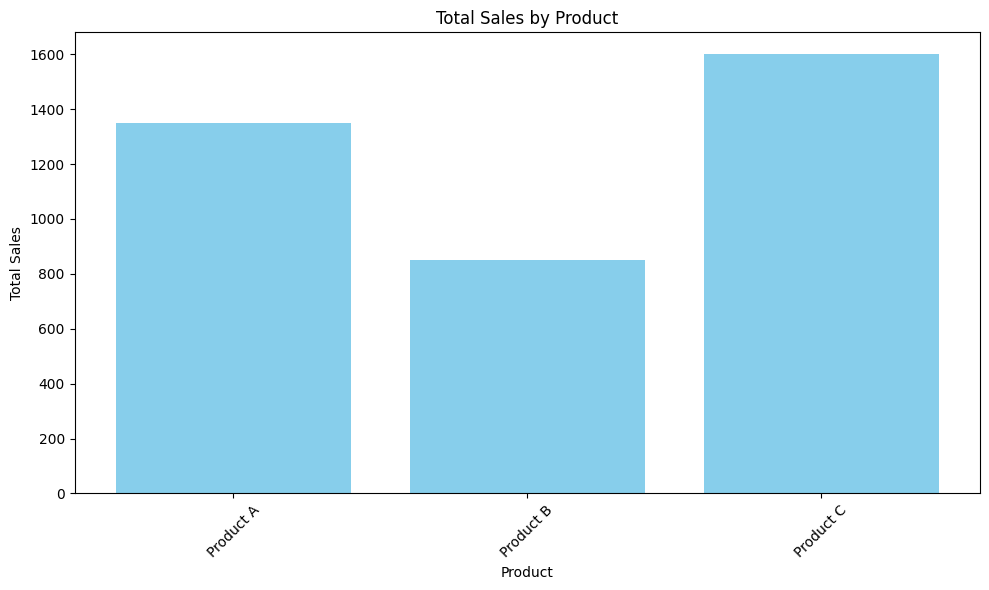

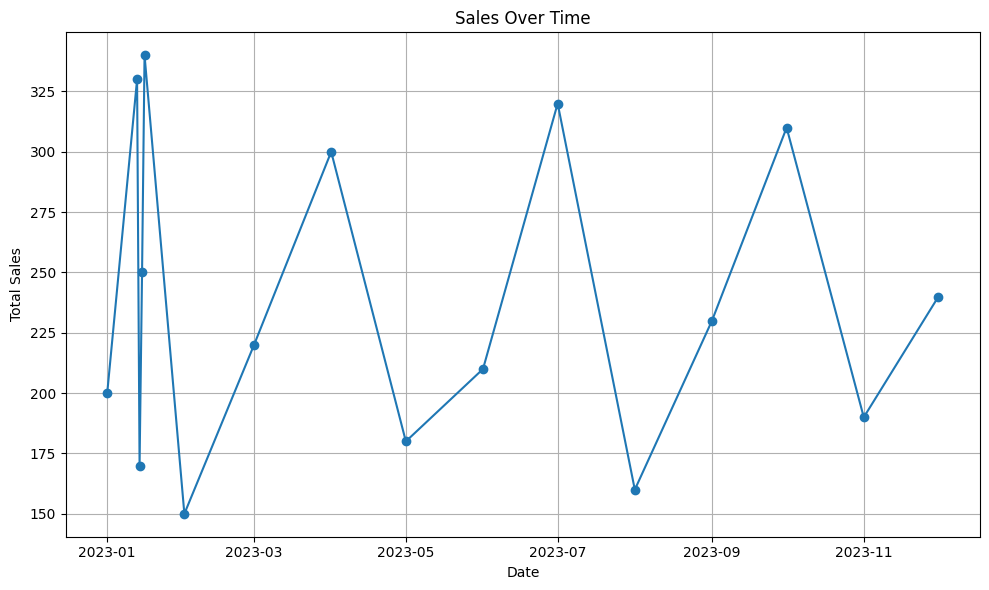

Product  Product A  Product B  Product C
Region                                  
East             0          0       1600
North         1350          0          0
South            0        480          0
West             0        370          0


/tmp/ipykernel_436/3745516394.py:53: FutureWarning: The provided callable <function sum at 0x7a3e1a521580> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  pivot_table = df.pivot_table(values='Sales', index='Region',


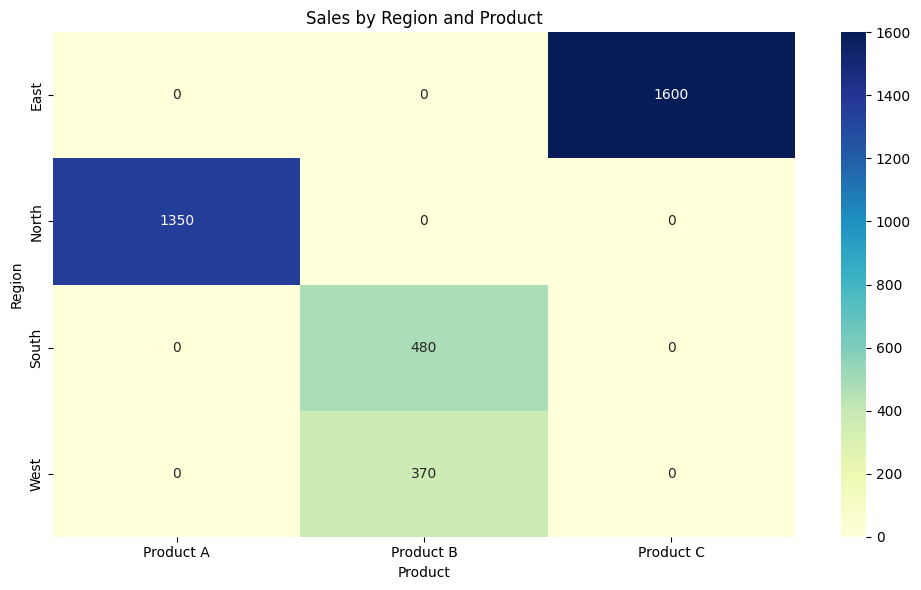

             Sales  Quantity
Sales     1.000000  0.944922
Quantity  0.944922  1.000000


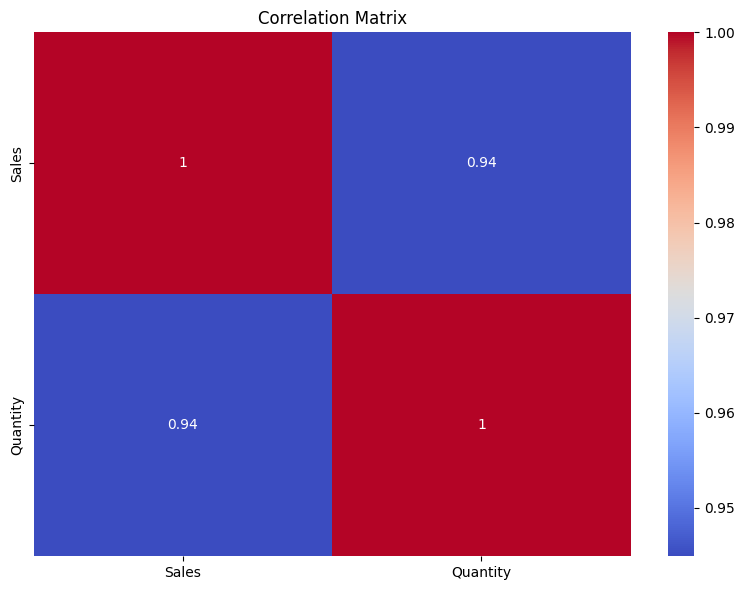

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data into a pandas DataFrame using pd.read_excel
df = pd.read_excel("sales_data.csv")

# Display the first few rows of the DataFrame
print(df.head())

# Check for missing values
print(df.isnull().sum())

# Fill or drop missing values if necessary
df['Sales'].fillna(df['Sales'].mean(), inplace=True)
df.dropna(subset=['Product', 'Quantity', 'Region'], inplace=True)

# Summary statistics
print(df.describe())

# Group by product and calculate the total sales and quantity
product_summary = df.groupby('Product').agg({
    'Sales': 'sum',
    'Quantity': 'sum'
}).reset_index()
print(product_summary)

# Bar plot of total sales by product
plt.figure(figsize=(10, 6))
plt.bar(product_summary['Product'], product_summary['Sales'], color='skyblue')
plt.xticks(rotation=45)
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.title('Total Sales by Product')
plt.tight_layout()
plt.show()

# Line plot of sales over time
df['Date'] = pd.to_datetime(df['Date'])
sales_over_time = df.groupby('Date').agg({'Sales': 'sum'}).reset_index()

plt.figure(figsize=(10, 6))
plt.plot(sales_over_time['Date'], sales_over_time['Sales'], marker='o', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.title('Sales Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

# Pivot table to analyze sales by region and product
pivot_table = df.pivot_table(values='Sales', index='Region',
                             columns='Product', aggfunc=np.sum, fill_value=0)
print(pivot_table)

# Heatmap of sales by region and product
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Sales by Region and Product")
plt.tight_layout()
plt.show()

# Correlation matrix (numeric columns only)
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)

# Heatmap of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()
